In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  

Shape: (6335, 4)

Columns:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

Missing Values:
Unnamed: 0    0
title         0
text          0
labe

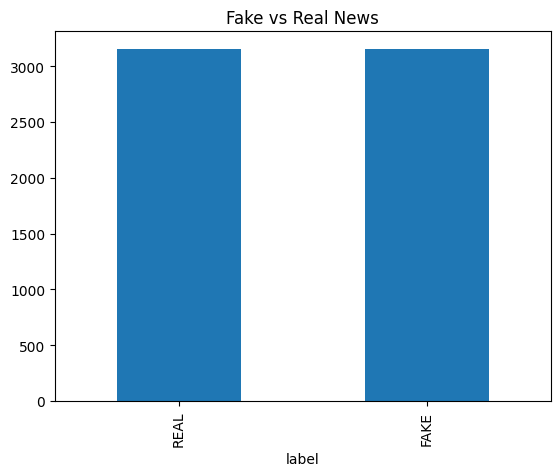

label
REAL    3154
FAKE    3152
Name: count, dtype: int64

LOGISTIC REGRESSION
Accuracy: 0.9120443740095087
              precision    recall  f1-score   support

        FAKE       0.90      0.93      0.91       631
        REAL       0.92      0.90      0.91       631

    accuracy                           0.91      1262
   macro avg       0.91      0.91      0.91      1262
weighted avg       0.91      0.91      0.91      1262

[[584  47]
 [ 64 567]]

LINEAR SVM
Accuracy: 0.927892234548336
              precision    recall  f1-score   support

        FAKE       0.93      0.93      0.93       631
        REAL       0.93      0.93      0.93       631

    accuracy                           0.93      1262
   macro avg       0.93      0.93      0.93      1262
weighted avg       0.93      0.93      0.93      1262

[[586  45]
 [ 46 585]]

 Logistic Regression
Accuracy: 0.9120443740095087
Precision: 0.9012345679012346
Recall: 0.9255150554675119
F1: 0.9132134480062549

 Linear SVM
Accuracy

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)





for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)





print(df.head())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())



df = df.drop(columns=["Unnamed: 0"], errors="ignore")



df = df.drop_duplicates()
df = df.dropna()




df["label"].value_counts().plot(
    kind="bar",
    title="Fake vs Real News"
)

plt.show()

print(df["label"].value_counts())




X = (
    df["title"].fillna("")
    + " "
    + df["text"].fillna("")
)

X = X.str.lower()

y = df["label"]





X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train = tfidf.fit_transform(X_train_text)

X_test = tfidf.transform(X_test_text)





model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

lr_pred = model.predict(X_test)

print("\nLOGISTIC REGRESSION")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)






svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("\nLINEAR SVM")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        svm_pred
    )
)

print(
    classification_report(
        y_test,
        svm_pred
    )
)

print(
    confusion_matrix(
        y_test,
        svm_pred
    )
)




models = {
    "Logistic Regression": model,
    "Linear SVM": svm
}

for name, clf in models.items():

    pred = clf.predict(X_test)

    print("\n", name)

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_test,
            pred,
            pos_label="FAKE"
        )
    )

    print(
        "Recall:",
        recall_score(
            y_test,
            pred,
            pos_label="FAKE"
        )
    )

    print(
        "F1:",
        f1_score(
            y_test,
            pred,
            pos_label="FAKE"
        )
    )




news = [
"""
India launches a new satellite mission successfully from Sriharikota.
Scientists say the mission will improve communication capabilities.
"""
]

news_vector = tfidf.transform(news)

print("\nCustom Prediction")

print(
    "Logistic:",
    model.predict(news_vector)[0]
)

print(
    "Probabilities:"
)

probs = model.predict_proba(news_vector)

for label, prob in zip(
    model.classes_,
    probs[0]
):
    print(label, ":", round(prob,4))

print(
    "SVM:",
    svm.predict(news_vector)[0]
)





for i in range(10):

    text = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    pred = svm.predict(
        tfidf.transform([text])
    )[0]

    print("\nArticle", i+1)

    print("Actual:", actual)

    print("Predicted:", pred)
    correct = 0

for i in range(len(X_test_text)):

    text = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    pred = svm.predict(
        tfidf.transform([text])
    )[0]

    if pred == actual:
        correct += 1

print("Correct Predictions:", correct)

print("Total Articles:", len(X_test_text))

print(
    "Accuracy:",
    correct / len(X_test_text)
)

joblib.dump(svm, "final_svm_model.pkl")

joblib.dump(
    tfidf,
    "final_tfidf_vectorizer.pkl"
)

import os


print("\nFiles Saved:")
print(os.listdir())

In [3]:


test_articles = [

"""The national weather department announced that several regions may experience heavy rainfall over the next week. Officials advised residents to monitor updates and avoid flooded areas.""",

"""Researchers at a university reported progress in developing batteries with longer charging cycles. The study is undergoing peer review before publication.""",
   
"""A city administration introduced new traffic regulations aimed at reducing congestion during peak hours. Authorities said implementation will begin next month.""",
    
"""Scientists confirm that drinking one glass of water instantly increases intelligence by 300 percent and permanently improves memory.""",
    
"""An online post claimed that all examinations across the country would be cancelled indefinitely, but no official announcement was attached.""",
    
"""A startup introduced software that helps users organize documents automatically using machine learning techniques.""",
    
"""Experts revealed that standing under moonlight for ten minutes can fully recharge the human body and eliminate the need for sleep.""",
    
"""The transportation department announced plans to expand public transit routes to improve connectivity between neighborhoods.""",
    
"""Social media posts claimed a newly discovered fruit allows people to avoid all illnesses without medical treatment.""",
    
"""A technology company released a report showing increased investment in renewable energy infrastructure over the pa year."""
    
]

for i, article in enumerate(test_articles):

    vector = tfidf.transform([article])

    prediction = svm.predict(vector)[0]

    print(f"\nArticle {i+1}")

    print("Prediction:", prediction)

    print("-"*40)


Article 1
Prediction: REAL
----------------------------------------

Article 2
Prediction: FAKE
----------------------------------------

Article 3
Prediction: FAKE
----------------------------------------

Article 4
Prediction: FAKE
----------------------------------------

Article 5
Prediction: REAL
----------------------------------------

Article 6
Prediction: FAKE
----------------------------------------

Article 7
Prediction: FAKE
----------------------------------------

Article 8
Prediction: FAKE
----------------------------------------

Article 9
Prediction: FAKE
----------------------------------------

Article 10
Prediction: FAKE
----------------------------------------


In [4]:

for i, article in enumerate(test_articles):

    vector = tfidf.transform([article])

    prediction = svm.predict(vector)[0]

    score = svm.decision_function(vector)[0]

    print(f"\nArticle {i+1}")

    print("Prediction:", prediction)

    print("Confidence Score:", round(score, 3))

    print("-"*40)


Article 1
Prediction: REAL
Confidence Score: 0.06
----------------------------------------

Article 2
Prediction: FAKE
Confidence Score: -0.52
----------------------------------------

Article 3
Prediction: FAKE
Confidence Score: -0.179
----------------------------------------

Article 4
Prediction: FAKE
Confidence Score: -0.746
----------------------------------------

Article 5
Prediction: REAL
Confidence Score: 0.104
----------------------------------------

Article 6
Prediction: FAKE
Confidence Score: -0.541
----------------------------------------

Article 7
Prediction: FAKE
Confidence Score: -0.722
----------------------------------------

Article 8
Prediction: FAKE
Confidence Score: -0.089
----------------------------------------

Article 9
Prediction: FAKE
Confidence Score: -1.084
----------------------------------------

Article 10
Prediction: FAKE
Confidence Score: -0.62
----------------------------------------


In [5]:
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score
import joblib

pac = PassiveAggressiveClassifier(
    max_iter=1000,
    random_state=42
)

pac.fit(X_train, y_train)

pac_pred = pac.predict(X_test)

print(
    "Passive Aggressive Accuracy:",
    accuracy_score(
        y_test,
        pac_pred
    )
)

# Save model
joblib.dump(
    pac,
    "passive_aggressive_model.pkl"
)

Passive Aggressive Accuracy: 0.9270998415213946


['passive_aggressive_model.pkl']

In [6]:
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score

pac2 = PassiveAggressiveClassifier(
    C=0.5,
    max_iter=2000,
    tol=0.001,
    random_state=42
)

pac2.fit(X_train, y_train)

pac2_pred = pac2.predict(X_test)

print(
    "Tuned PAC Accuracy:",
    accuracy_score(
        y_test,
        pac2_pred
    )
)

import joblib

joblib.dump(
    pac2,
    "tuned_pac_model.pkl"
)

Tuned PAC Accuracy: 0.9247226624405706


['tuned_pac_model.pkl']

In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nb_model = MultinomialNB()


nb_model.fit(X_train, y_train)


nb_pred = nb_model.predict(X_test)


print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))


print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, nb_pred))

Naive Bayes Accuracy: 0.884310618066561

Classification Report:

              precision    recall  f1-score   support

        FAKE       0.86      0.91      0.89       631
        REAL       0.91      0.86      0.88       631

    accuracy                           0.88      1262
   macro avg       0.89      0.88      0.88      1262
weighted avg       0.89      0.88      0.88      1262


Confusion Matrix:

[[576  55]
 [ 91 540]]


In [8]:
news = ["""
India announces new space mission to improve satellite communication systems.
"""]

vector = tfidf.transform(news)

prediction = nb_model.predict(vector)

print("Prediction:", prediction[0])

Prediction: FAKE


In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": model,
    "Linear SVM": svm,
    "Passive Aggressive": pac,  
    "Naive Bayes": nb_model
}

for name, clf in models.items():

    pred = clf.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, pos_label="FAKE"))
    print("Recall:", recall_score(y_test, pred, pos_label="FAKE"))
    print("F1 Score:", f1_score(y_test, pred, pos_label="FAKE"))


 Logistic Regression
Accuracy: 0.9120443740095087
Precision: 0.9012345679012346
Recall: 0.9255150554675119
F1 Score: 0.9132134480062549

 Linear SVM
Accuracy: 0.927892234548336
Precision: 0.9272151898734177
Recall: 0.9286846275752774
F1 Score: 0.9279493269992082

 Passive Aggressive
Accuracy: 0.9270998415213946
Precision: 0.9298245614035088
Recall: 0.9239302694136292
F1 Score: 0.9268680445151033

 Naive Bayes
Accuracy: 0.884310618066561
Precision: 0.863568215892054
Recall: 0.9128367670364501
F1 Score: 0.8875192604006163


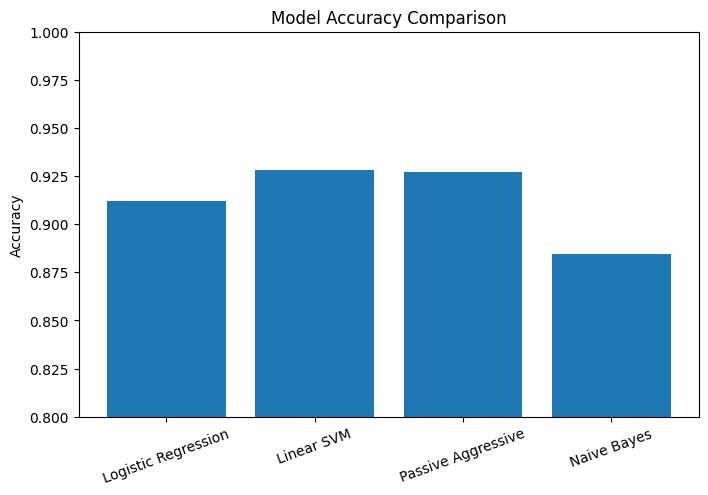

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


log_acc = accuracy_score(y_test, model.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
pac_acc = accuracy_score(y_test, pac.predict(X_test))
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))


models = [
    "Logistic Regression",
    "Linear SVM",
    "Passive Aggressive",
    "Naive Bayes"
]


accuracy = [log_acc, svm_acc, pac_acc, nb_acc]


plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.80, 1.0)

plt.xticks(rotation=20)
plt.show()

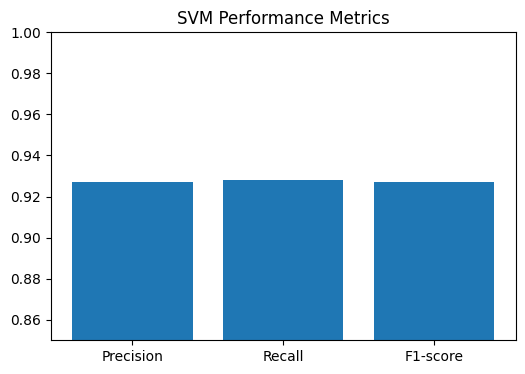

In [12]:
metrics = ["Precision", "Recall", "F1-score"]
scores = [0.927, 0.928, 0.927]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores)

plt.title("SVM Performance Metrics")
plt.ylim(0.85, 1.0)

plt.show()

In [13]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": model,
    "Linear SVM": svm,
    "Passive Aggressive": pac,
    "Naive Bayes": nb_model
}

results = []

for name, clf in models.items():

    y_pred = clf.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, pos_label="FAKE"),
        recall_score(y_test, y_pred, pos_label="FAKE"),
        f1_score(y_test, y_pred, pos_label="FAKE")
    ])

df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

df_results

df_results.style.highlight_max(axis=0)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.912044,0.901235,0.925515,0.913213
1,Linear SVM,0.927892,0.927215,0.928685,0.927949
2,Passive Aggressive,0.927100,0.929825,0.923930,0.926868
3,Naive Bayes,0.884311,0.863568,0.912837,0.887519


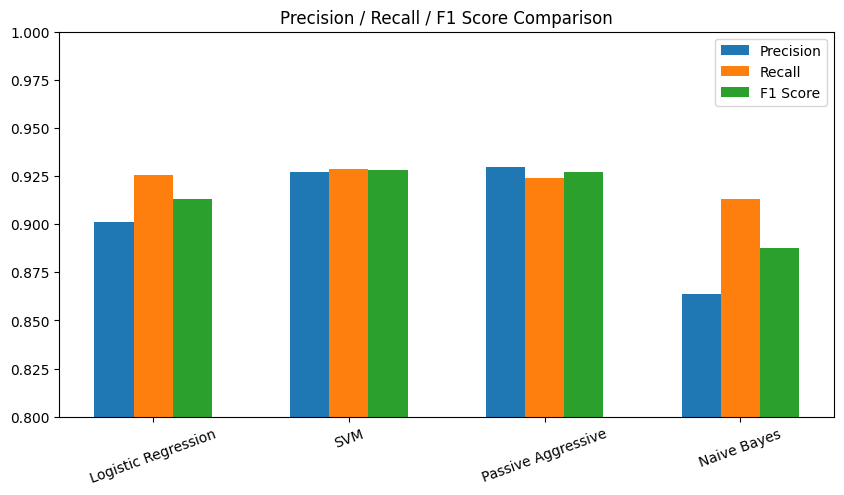

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score


log_prec = precision_score(y_test, model.predict(X_test), pos_label="FAKE")
log_rec = recall_score(y_test, model.predict(X_test), pos_label="FAKE")
log_f1 = f1_score(y_test, model.predict(X_test), pos_label="FAKE")


svm_prec = precision_score(y_test, svm.predict(X_test), pos_label="FAKE")
svm_rec = recall_score(y_test, svm.predict(X_test), pos_label="FAKE")
svm_f1 = f1_score(y_test, svm.predict(X_test), pos_label="FAKE")


pac_prec = precision_score(y_test, pac.predict(X_test), pos_label="FAKE")
pac_rec = recall_score(y_test, pac.predict(X_test), pos_label="FAKE")
pac_f1 = f1_score(y_test, pac.predict(X_test), pos_label="FAKE")


nb_prec = precision_score(y_test, nb_model.predict(X_test), pos_label="FAKE")
nb_rec = recall_score(y_test, nb_model.predict(X_test), pos_label="FAKE")
nb_f1 = f1_score(y_test, nb_model.predict(X_test), pos_label="FAKE")

models = ["Logistic Regression", "SVM", "Passive Aggressive", "Naive Bayes"]

precision = [log_prec, svm_prec, pac_prec, nb_prec]
recall = [log_rec, svm_rec, pac_rec, nb_rec]
f1 = [log_f1, svm_f1, pac_f1, nb_f1]

x = range(len(models))

plt.figure(figsize=(10,5))

plt.bar([i - 0.2 for i in x], precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar([i + 0.2 for i in x], f1, width=0.2, label="F1 Score")

plt.xticks(x, models, rotation=20)
plt.ylim(0.80, 1.0)
plt.title("Precision / Recall / F1 Score Comparison")
plt.legend()

plt.show()

In [15]:
correct = 0

for i in range(len(X_test_text)):

    article = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    predicted = svm.predict(
        tfidf.transform([article])
    )[0]

    if predicted == actual:
        correct += 1

print("Correct Predictions:", correct)

print("Total Articles:", len(X_test_text))

print(
    "Prediction Accuracy:",
    round(
        correct / len(X_test_text) * 100,
        2
    ),
    "%"
)

Correct Predictions: 1171
Total Articles: 1262
Prediction Accuracy: 92.79 %


In [16]:
for i in range(len(X_test_text)):

    article = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    predicted = svm.predict(
        tfidf.transform([article])
    )[0]

    if predicted != actual:

        print("\nActual:", actual)

        print("Predicted:", predicted)

        print(article[:300])

        print("-"*50)


Actual: FAKE
Predicted: REAL
how to repair strained or broken relationships a subject not often discussed is the topic of how to repair strained or broken relationships. it is one that comes up in everyone’s life, so it will be useful to make a few suggestions about it here. we will talk about relationships from friends, family
--------------------------------------------------

Actual: REAL
Predicted: FAKE
cuba has a possible lung cancer vaccine that america can now test the united states and cuba have taken major steps to end their 50 years of hostility, and some researchers think americans could reap an unexpected benefit: better access to cuban medical innovations.

"the us may be the world leader 
--------------------------------------------------

Actual: REAL
Predicted: FAKE
profit sharing was supposed to be a silver bullet for middle-class success. what happened? the core commitment of the american economy to give workers a fair share of the productivity and profits they have 

In [17]:
for i in range(10):

    article = X_test_text.iloc[i]

    actual = y_test.iloc[i]

    predicted = svm.predict(
        tfidf.transform([article])
    )[0]

    print("\nArticle", i+1)

    print("Actual:", actual)

    print("Predicted:", predicted)

    if predicted == actual:
        print("Result: Correct")

    else:
        print("Result: Wrong")

    print("-"*40)


Article 1
Actual: REAL
Predicted: REAL
Result: Correct
----------------------------------------

Article 2
Actual: FAKE
Predicted: FAKE
Result: Correct
----------------------------------------

Article 3
Actual: FAKE
Predicted: FAKE
Result: Correct
----------------------------------------

Article 4
Actual: REAL
Predicted: REAL
Result: Correct
----------------------------------------

Article 5
Actual: FAKE
Predicted: FAKE
Result: Correct
----------------------------------------

Article 6
Actual: FAKE
Predicted: REAL
Result: Wrong
----------------------------------------

Article 7
Actual: FAKE
Predicted: FAKE
Result: Correct
----------------------------------------

Article 8
Actual: REAL
Predicted: REAL
Result: Correct
----------------------------------------

Article 9
Actual: FAKE
Predicted: FAKE
Result: Correct
----------------------------------------

Article 10
Actual: REAL
Predicted: REAL
Result: Correct
----------------------------------------


In [18]:
test_articles = [

("REAL",
"""The national weather department announced that several regions may experience heavy rainfall over the next week. Officials advised residents to monitor updates and avoid flooded areas."""),

("REAL",
"""Researchers at a university reported progress in developing batteries with longer charging cycles. The study is undergoing peer review before publication."""),

("REAL",
"""A city administration introduced new traffic regulations aimed at reducing congestion during peak hours. Authorities said implementation will begin next month."""),

("FAKE",
"""Scientists confirm that drinking one glass of water instantly increases intelligence by 300 percent and permanently improves memory."""),

("FAKE",
"""An online post claimed that all examinations across the country would be cancelled indefinitely, but no official announcement was attached."""),

("REAL",
"""A startup introduced software that helps users organize documents automatically using machine learning techniques."""),

("FAKE",
"""Experts revealed that standing under moonlight for ten minutes can fully recharge the human body and eliminate the need for sleep."""),

("REAL",
"""The transportation department announced plans to expand public transit routes to improve connectivity between neighborhoods."""),

("FAKE",
"""Social media posts claimed a newly discovered fruit allows people to avoid all illnesses without medical treatment."""),

("REAL",
"""A technology company released a report showing increased investment in renewable energy infrastructure over the past year.""")
]

correct = 0

for i, (actual, article) in enumerate(test_articles):

    vector = tfidf.transform([article])

    pred = svm.predict(vector)[0]

    confidence = svm.decision_function(vector)[0]

    print(f"\nArticle {i+1}")

    print("Expected:", actual)

    print("Predicted:", pred)

    print(
        "Confidence:",
        round(confidence, 3)
    )

    if pred == actual:
        print("Result: Correct")
        correct += 1
    else:
        print("Result: Wrong")

    print("-"*40)

print(
    "\nCustom Article Accuracy:",
    round(
        correct / len(test_articles) * 100,
        2
    ),
    "%"
)



Article 1
Expected: REAL
Predicted: REAL
Confidence: 0.06
Result: Correct
----------------------------------------

Article 2
Expected: REAL
Predicted: FAKE
Confidence: -0.52
Result: Wrong
----------------------------------------

Article 3
Expected: REAL
Predicted: FAKE
Confidence: -0.179
Result: Wrong
----------------------------------------

Article 4
Expected: FAKE
Predicted: FAKE
Confidence: -0.746
Result: Correct
----------------------------------------

Article 5
Expected: FAKE
Predicted: REAL
Confidence: 0.104
Result: Wrong
----------------------------------------

Article 6
Expected: REAL
Predicted: FAKE
Confidence: -0.541
Result: Wrong
----------------------------------------

Article 7
Expected: FAKE
Predicted: FAKE
Confidence: -0.722
Result: Correct
----------------------------------------

Article 8
Expected: REAL
Predicted: FAKE
Confidence: -0.089
Result: Wrong
----------------------------------------

Article 9
Expected: FAKE
Predicted: FAKE
Confidence: -1.084
Result: C

In [19]:
correct = 0

for i, (actual, article) in enumerate(test_articles):

    pred = svm.predict(
        tfidf.transform([article])
    )[0]

    print("\nArticle", i+1)

    print("Expected:", actual)

    print("Predicted:", pred)

    if pred == actual:
        print(" Correct")
        correct += 1
    else:
        print(" Wrong")

print("\nCorrect:", correct)

print("Total:", len(test_articles))


Article 1
Expected: REAL
Predicted: REAL
 Correct

Article 2
Expected: REAL
Predicted: FAKE
 Wrong

Article 3
Expected: REAL
Predicted: FAKE
 Wrong

Article 4
Expected: FAKE
Predicted: FAKE
 Correct

Article 5
Expected: FAKE
Predicted: REAL
 Wrong

Article 6
Expected: REAL
Predicted: FAKE
 Wrong

Article 7
Expected: FAKE
Predicted: FAKE
 Correct

Article 8
Expected: REAL
Predicted: FAKE
 Wrong

Article 9
Expected: FAKE
Predicted: FAKE
 Correct

Article 10
Expected: REAL
Predicted: FAKE
 Wrong

Correct: 4
Total: 10


In [20]:
test_articles = [

("REAL",
"""Government officials reported that more than 1400 online links were blocked during an operation targeting misinformation and fake news dissemination."""),

("REAL",
"""Researchers continue developing improved battery technologies with longer life cycles and publish results after scientific review."""),

("REAL",
"""Public transportation authorities announced expansion plans to improve connectivity and reduce congestion in urban areas."""),

("FAKE",
"""Scientists proved that drinking one glass of water instantly increases intelligence permanently."""),

("FAKE",
"""A viral post claimed old videos showed current international conflict events, but the footage was unrelated."""),

("REAL",
"""Technology companies continue increasing investment in renewable energy infrastructure according to annual reporting."""),

("FAKE",
"""Social media users claimed moonlight exposure completely removes the human need for sleep."""),

("REAL",
"""Weather departments regularly issue heavy rainfall alerts and advise people to monitor official updates."""),

("FAKE",
"""A viral claim stated one fruit prevents all diseases without medical treatment."""),

("FAKE",
"""An online message claimed all examinations nationwide were cancelled indefinitely without any official announcement.""")
]

correct = 0

for i, (actual, article) in enumerate(test_articles):

    vector = tfidf.transform([article])

    pred = svm.predict(vector)[0]

    confidence = svm.decision_function(vector)[0]

    print(f"\nArticle {i+1}")

    print("Expected:", actual)

    print("Predicted:", pred)

    print("Confidence:", round(confidence, 3))

    if pred == actual:
        print("Result: Correct")
        correct += 1
    else:
        print("Result: Wrong")

    print("-"*40)

print(
    "\nAccuracy:",
    round(correct / len(test_articles) * 100, 2),
    "%"
)


Article 1
Expected: REAL
Predicted: FAKE
Confidence: -0.212
Result: Wrong
----------------------------------------

Article 2
Expected: REAL
Predicted: FAKE
Confidence: -0.835
Result: Wrong
----------------------------------------

Article 3
Expected: REAL
Predicted: FAKE
Confidence: -0.373
Result: Wrong
----------------------------------------

Article 4
Expected: FAKE
Predicted: FAKE
Confidence: -0.658
Result: Correct
----------------------------------------

Article 5
Expected: FAKE
Predicted: FAKE
Confidence: -0.451
Result: Correct
----------------------------------------

Article 6
Expected: REAL
Predicted: FAKE
Confidence: -0.795
Result: Wrong
----------------------------------------

Article 7
Expected: FAKE
Predicted: FAKE
Confidence: -0.679
Result: Correct
----------------------------------------

Article 8
Expected: REAL
Predicted: REAL
Confidence: 0.009
Result: Correct
----------------------------------------

Article 9
Expected: FAKE
Predicted: FAKE
Confidence: -1.177
Resu